
# TP2 - Clase 3: Detector de Máximo Enfoque en Frecuencia

**Objetivo:** implementar un detector de máximo enfoque sobre un video, usando la métrica
propuesta en el paper *"Image Sharpness Measure for Blurred Images in Frequency Domain"*
(De & Masilamani, 2013), y evaluarla:

1. Sobre el frame completo.
2. Sobre una ROI central (5% o 10% del área del frame).

El algoritmo debe detectar automáticamente el/los frame(s) de máximo enfoque.

**Extra:** aplicar *unsharp masking* para expandir la zona de enfoque.


## 1. Imports

In [17]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)



## 2. La métrica FM (Frequency Domain Blur Measure)

Recordemos el algoritmo del paper (Sección 3.1):

1. Calcular $F$ = FFT2D de la imagen $I$ (en escala de grises).
2. Centrar el espectro: $F_c = \text{fftshift}(F)$.
3. Calcular la magnitud: $AF = |F_c|$.
4. Calcular el máximo: $M = \max(AF)$.
5. Definir el umbral: $thres = M / 1000$.
6. Contar $T_H$ = cantidad de píxeles de $AF$ que superan $thres$.
7. Calcular la métrica final:

$$FM = \frac{T_H}{M_{rows} \times N_{cols}}$$

Cuanto más nítida la imagen, más energía hay en componentes de alta frecuencia
(que quedan repartidas por todo el espectro tras el centrado), por lo que más píxeles
superan el umbral y el valor de FM es mayor.


In [18]:

def frequency_sharpness_measure(gray_img: np.ndarray) -> float:
    """
    Calcula la métrica FM (Image Quality Measure) del paper de De & Masilamani (2013).

    Parameters
    ----------
    gray_img : np.ndarray
        Imagen en escala de grises (2D), dtype float o uint8.

    Returns
    -------
    fm : float
        Valor de la métrica de nitidez. A mayor valor, imagen más enfocada/nítida.
    """
    img = gray_img.astype(np.float64)
    rows, cols = img.shape

    # Paso 1: FFT2D
    F = np.fft.fft2(img)

    # Paso 2: centrar el espectro
    Fc = np.fft.fftshift(F)

    # Paso 3: magnitud
    AF = np.abs(Fc)

    # Paso 4: máximo
    M = AF.max()
    if M == 0:
        return 0.0

    # Paso 5: umbral
    thres = M / 1000.0

    # Paso 6: conteo de componentes de alta frecuencia
    TH = np.count_nonzero(AF > thres)

    # Paso 7: métrica final
    fm = TH / (rows * cols)
    return fm


### Sanity check rápido: comparamos una imagen nítida vs. una version desenfocada

FM imagen nítida  : 0.0744
FM imagen borrosa : 0.0208


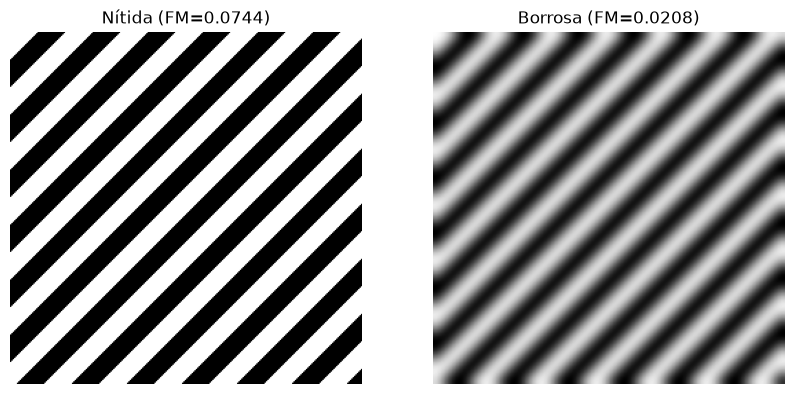

La imagen nítida tiene un valor FM mayor que la imagen borrosa, como se esperaba.


In [19]:

# Generamos una imagen sintética con bordes (checkerboard) para validar la métrica
size = 256
checker = np.indices((size, size)).sum(axis=0) % 40 < 20
checker = (checker * 255).astype(np.uint8)

blurred = cv2.GaussianBlur(checker, (0, 0), sigmaX=5)

fm_sharp = frequency_sharpness_measure(checker)
fm_blur = frequency_sharpness_measure(blurred)

print(f"FM imagen nítida  : {fm_sharp:.4f}")
print(f"FM imagen borrosa : {fm_blur:.4f}")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(checker, cmap='gray'); axs[0].set_title(f"Nítida (FM={fm_sharp:.4f})"); axs[0].axis('off')
axs[1].imshow(blurred, cmap='gray'); axs[1].set_title(f"Borrosa (FM={fm_blur:.4f})"); axs[1].axis('off')
plt.show()

if fm_sharp > fm_blur:
    print("La imagen nítida tiene un valor FM mayor que la imagen borrosa, como se esperaba.")
else:
    print("La imagen nítida no tiene un valor FM mayor que la imagen borrosa.")



## 3. Carga del video




In [20]:

VIDEO_PATH = Path("focus_video.mov")  # <-- ajustar ruta

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise IOError(f"No se pudo abrir el video: {VIDEO_PATH}")

n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Frames: {n_frames} | FPS: {fps:.2f} | Resolución: {width}x{height}")


Frames: 171 | FPS: 29.97 | Resolución: 640x360



## 4. Extracción de frames y cálculo de la métrica

Leemos todos los frames una sola vez y guardamos:
- El frame completo en escala de grises.
- El FM sobre el frame completo.
- El FM sobre una ROI central (definimos el área como % del área total).


In [21]:

def get_center_roi(gray_img: np.ndarray, area_fraction: float) -> np.ndarray:
    """
    Devuelve una ROI cuadrada centrada cuya área es aproximadamente
    `area_fraction` del área total de la imagen.
    """
    h, w = gray_img.shape
    total_area = h * w
    roi_area = total_area * area_fraction
    side = int(np.sqrt(roi_area))

    cy, cx = h // 2, w // 2
    half = side // 2

    y0, y1 = max(cy - half, 0), min(cy + half, h)
    x0, x1 = max(cx - half, 0), min(cx + half, w)

    return gray_img[y0:y1, x0:x1], (x0, y0, x1, y1)


In [22]:

ROI_FRACTION = 0.10  # 10% del área total (probar también con 0.05)

frames_gray = []
fm_full = []
fm_roi = []
roi_boxes = []

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames_gray.append(gray)

    fm_full.append(frequency_sharpness_measure(gray))

    roi, box = get_center_roi(gray, ROI_FRACTION)
    fm_roi.append(frequency_sharpness_measure(roi))
    roi_boxes.append(box)

cap.release()

fm_full = np.array(fm_full)
fm_roi = np.array(fm_roi)

print(f"Frames procesados: {len(frames_gray)}")


Frames procesados: 171



## 5. Detección automática del punto de máximo enfoque

Buscamos el/los frame(s) donde la métrica es máxima. Como la señal puede tener ruido
frame a frame, aplicamos un suavizado leve (media móvil) antes de buscar el máximo,
para evitar detectar un pico espurio.


In [23]:

def smooth(signal: np.ndarray, window: int = 5) -> np.ndarray:
    """Media móvil simple para suavizar la curva de la métrica."""
    if window <= 1:
        return signal
    kernel = np.ones(window) / window
    return np.convolve(signal, kernel, mode='same')

def detect_focus_peak(signal: np.ndarray, window: int = 5):
    """
    Devuelve el índice de frame de máximo enfoque, junto con la señal suavizada.
    """
    smoothed = smooth(signal, window)
    peak_idx = int(np.argmax(smoothed))
    return peak_idx, smoothed


In [24]:
peak_idx_full, fm_full_smooth = detect_focus_peak(fm_full, window=5)
peak_idx_roi, fm_roi_smooth = detect_focus_peak(fm_roi, window=5)

print(f"Frame de máximo enfoque (imagen completa) : {peak_idx_full}  (FM={fm_full[peak_idx_full]:.4f})")
print(f"Frame de máximo enfoque (ROI central)      : {peak_idx_roi}  (FM={fm_roi[peak_idx_roi]:.4f})")


Frame de máximo enfoque (imagen completa) : 109  (FM=0.0286)
Frame de máximo enfoque (ROI central)      : 111  (FM=0.3506)


## 6. Gráficos: evolución de la métrica frame a frame

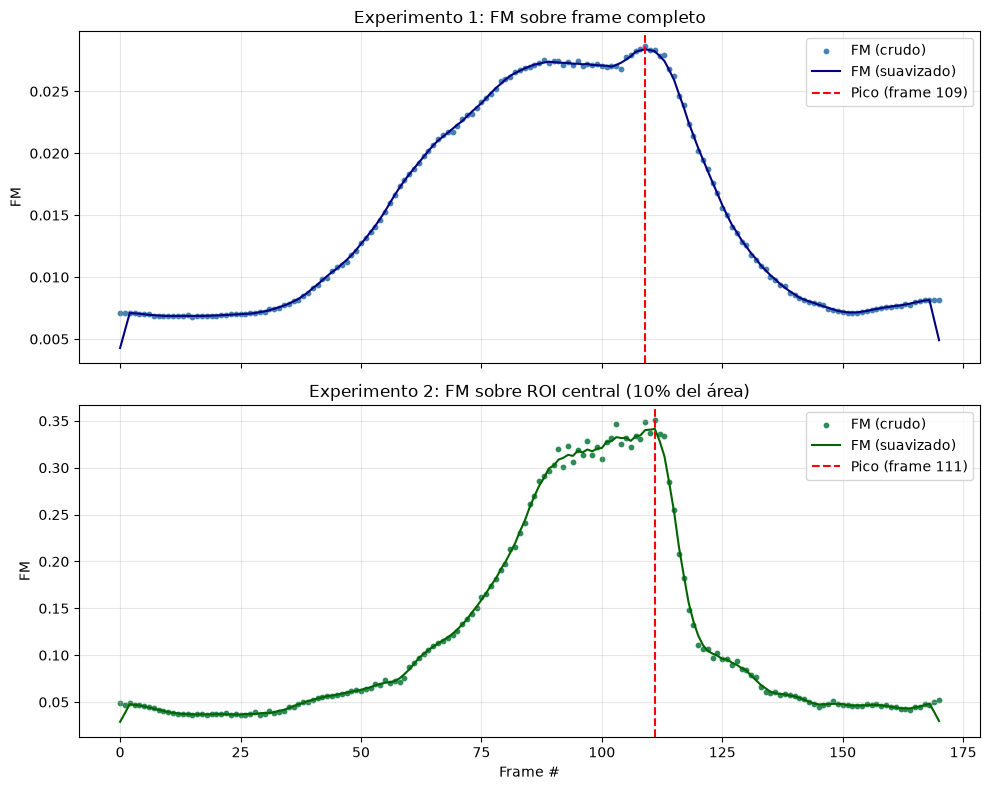

In [25]:

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].scatter(range(len(fm_full)), fm_full, s=10, color='steelblue', label='FM (crudo)')
axs[0].plot(fm_full_smooth, color='navy', linewidth=1.5, label='FM (suavizado)')
axs[0].axvline(peak_idx_full, color='red', linestyle='--', label=f'Pico (frame {peak_idx_full})')
axs[0].set_title('Experimento 1: FM sobre frame completo')
axs[0].set_ylabel('FM')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].scatter(range(len(fm_roi)), fm_roi, s=10, color='seagreen', label='FM (crudo)')
axs[1].plot(fm_roi_smooth, color='darkgreen', linewidth=1.5, label='FM (suavizado)')
axs[1].axvline(peak_idx_roi, color='red', linestyle='--', label=f'Pico (frame {peak_idx_roi})')
axs[1].set_title(f'Experimento 2: FM sobre ROI central ({int(ROI_FRACTION*100)}% del área)')
axs[1].set_xlabel('Frame #')
axs[1].set_ylabel('FM')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Visualización del frame detectado como más enfocado

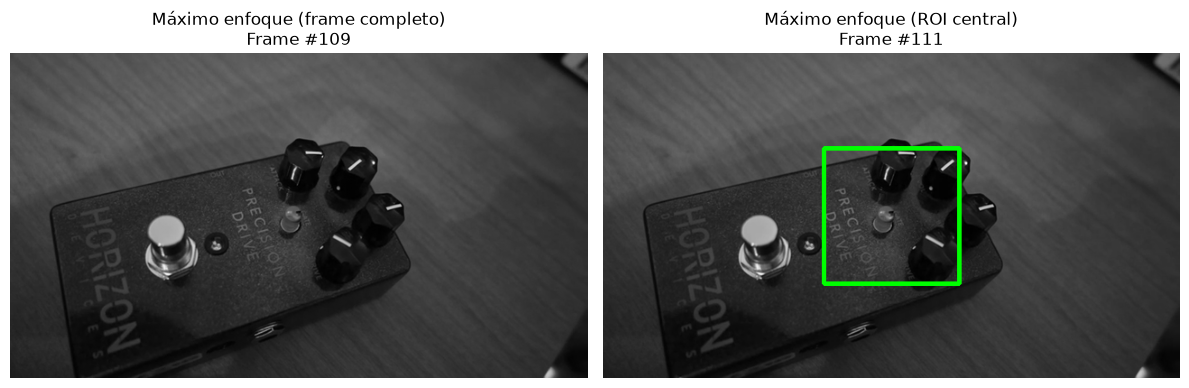

In [26]:

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(frames_gray[peak_idx_full], cmap='gray')
axs[0].set_title(f'Máximo enfoque (frame completo)\nFrame #{peak_idx_full}')
axs[0].axis('off')

img_roi_marked = cv2.cvtColor(frames_gray[peak_idx_roi], cv2.COLOR_GRAY2BGR)
x0, y0, x1, y1 = roi_boxes[peak_idx_roi]
cv2.rectangle(img_roi_marked, (x0, y0), (x1, y1), (0, 255, 0), 3)
axs[1].imshow(cv2.cvtColor(img_roi_marked, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'Máximo enfoque (ROI central)\nFrame #{peak_idx_roi}')
axs[1].axis('off')

plt.tight_layout()
plt.show()


## 7.b Detección del punto espacial de máximo enfoque

Hasta ahora sabíamos **cuándo** (qué frame) está más enfocado el video, pero no **dónde**
dentro de la imagen. Para encontrar el punto exacto, escaneamos el frame con una ventana
deslizante, calculamos el FM en cada posición, y nos quedamos con el centro de la ventana
que tiene el valor más alto.

In [27]:
def find_max_focus_point(gray_img: np.ndarray, patch_size: int = 60, stride: int = 30):
    """
    Escanea la imagen con una ventana deslizante y devuelve la posición
    (punto espacial) donde el FM es máximo.

    Parameters
    ----------
    gray_img : np.ndarray
        Imagen en escala de grises.
    patch_size : int
        Tamaño (lado) de la ventana deslizante, en píxeles.
    stride : int
        Paso de desplazamiento de la ventana. stride < patch_size => ventanas solapadas
        (mayor resolución espacial, más cómputo).

    Returns
    -------
    dict con: x_center, y_center, fm_value, x0, y0, x1, y1
    """
    h, w = gray_img.shape
    best = None

    for y0 in range(0, h - patch_size + 1, stride):
        for x0 in range(0, w - patch_size + 1, stride):
            y1, x1 = y0 + patch_size, x0 + patch_size
            patch = gray_img[y0:y1, x0:x1]
            fm = frequency_sharpness_measure(patch)

            if best is None or fm > best["fm_value"]:
                best = {
                    "x_center": (x0 + x1) // 2, "y_center": (y0 + y1) // 2,
                    "fm_value": fm,
                    "x0": x0, "y0": y0, "x1": x1, "y1": y1,
                }
    return best

In [28]:
PATCH_SIZE = 60
STRIDE = 6

# Punto de máximo enfoque dentro del frame más enfocado (experimento 1)
point_full = find_max_focus_point(frames_gray[peak_idx_full], PATCH_SIZE, STRIDE)

# Punto de máximo enfoque dentro del frame más enfocado en la ROI (experimento 2)
point_roi = find_max_focus_point(frames_gray[peak_idx_roi], PATCH_SIZE, STRIDE)

print(f"Punto de máx. enfoque (frame completo, #{peak_idx_full}): "
      f"({point_full['x_center']}, {point_full['y_center']})  FM={point_full['fm_value']:.4f}")
print(f"Punto de máx. enfoque (ROI central, #{peak_idx_roi}): "
      f"({point_roi['x_center']}, {point_roi['y_center']})  FM={point_roi['fm_value']:.4f}")

Punto de máx. enfoque (frame completo, #109): (390, 174)  FM=0.8717
Punto de máx. enfoque (ROI central, #111): (390, 174)  FM=0.8606


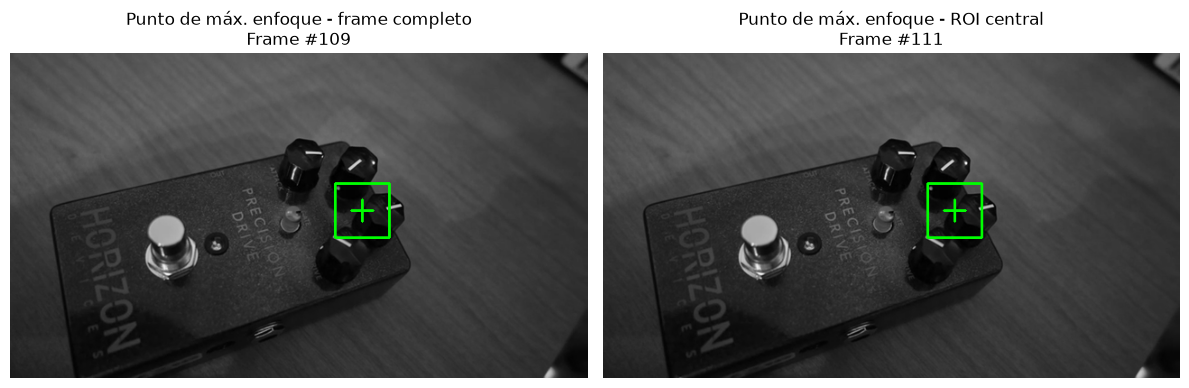

In [29]:
def mark_point(gray_img: np.ndarray, point: dict, color=(0, 255, 0)) -> np.ndarray:
    """Dibuja un recuadro + cruz sobre el punto de máximo enfoque detectado."""
    img = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(img, (point["x0"], point["y0"]), (point["x1"], point["y1"]), color, 2)
    cv2.drawMarker(img, (point["x_center"], point["y_center"]), color,
                    markerType=cv2.MARKER_CROSS, markerSize=25, thickness=2)
    return img

img_marked_full = mark_point(frames_gray[peak_idx_full], point_full)
img_marked_roi = mark_point(frames_gray[peak_idx_roi], point_roi)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv2.cvtColor(img_marked_full, cv2.COLOR_BGR2RGB))
axs[0].set_title(f'Punto de máx. enfoque - frame completo\nFrame #{peak_idx_full}')
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(img_marked_roi, cv2.COLOR_BGR2RGB))
axs[1].set_title(f'Punto de máx. enfoque - ROI central\nFrame #{peak_idx_roi}')
axs[1].axis('off')

plt.tight_layout()
plt.show()


## 8. Puntos extra: Unsharp Masking para expandir la zona de enfoque

Aplicamos la fórmula genérica vista en la clase:

$$g(x,y) = (k+1) \cdot f(x,y) - k \cdot f_B(x,y)$$

donde $f_B$ es una versión suavizada (Gaussiana) de la imagen, y $k$ controla
la intensidad del realce ($k=1$: unsharp masking clásico; $k>1$: highboost filtering).

La idea es que, al realzar los bordes de zonas parcialmente desenfocadas, la métrica FM
detecte como "enfocados" más frames alrededor del pico real, expandiendo la región
utilizable.


In [30]:

def unsharp_mask(gray_img: np.ndarray, k: float = 1.0, sigma: float = 3.0) -> np.ndarray:
    """
    Aplica unsharp masking / highboost filtering.

    Parameters
    ----------
    k : float
        k=1 -> unsharp masking clásico. k>1 -> highboost filtering.
    sigma : float
        Desvío estándar del filtro Gaussiano usado para desenfocar.
    """
    img = gray_img.astype(np.float64)
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)
    sharpened = (k + 1) * img - k * blurred
    return np.clip(sharpened, 0, 255).astype(np.uint8)


In [31]:

K_UNSHARP = 1.0
SIGMA_UNSHARP = 3.0

fm_full_unsharp = np.array([
    frequency_sharpness_measure(unsharp_mask(g, k=K_UNSHARP, sigma=SIGMA_UNSHARP))
    for g in frames_gray
])

peak_idx_full_unsharp, fm_full_unsharp_smooth = detect_focus_peak(fm_full_unsharp, window=5)

# Definimos "zona de enfoque" como los frames cuyo FM suavizado supera
# un porcentaje del pico (p. ej. 90%), antes y después de aplicar unsharp masking.
def focus_zone(smoothed_signal: np.ndarray, peak_idx: int, rel_thresh: float = 0.9):
    peak_val = smoothed_signal[peak_idx]
    mask = smoothed_signal >= rel_thresh * peak_val
    idxs = np.where(mask)[0]
    return idxs.min(), idxs.max()

start_orig, end_orig = focus_zone(fm_full_smooth, peak_idx_full)
start_unsharp, end_unsharp = focus_zone(fm_full_unsharp_smooth, peak_idx_full_unsharp)

print(f"Zona de enfoque (original)       : frames {start_orig} a {end_orig}  (ancho={end_orig-start_orig})")
print(f"Zona de enfoque (unsharp masking): frames {start_unsharp} a {end_unsharp}  (ancho={end_unsharp-start_unsharp})")


Zona de enfoque (original)       : frames 79 a 115  (ancho=36)
Zona de enfoque (unsharp masking): frames 83 a 114  (ancho=31)


### Comparación visual: imagen pre y post filtrado

Antes de ver el efecto agregado en la curva de FM, veamos directamente cómo cambia
la imagen. Mostramos el frame completo y también un recorte (zoom) alrededor del
punto de máximo enfoque detectado en la Sección 7.b, donde el realce de bordes se
aprecia con más claridad.

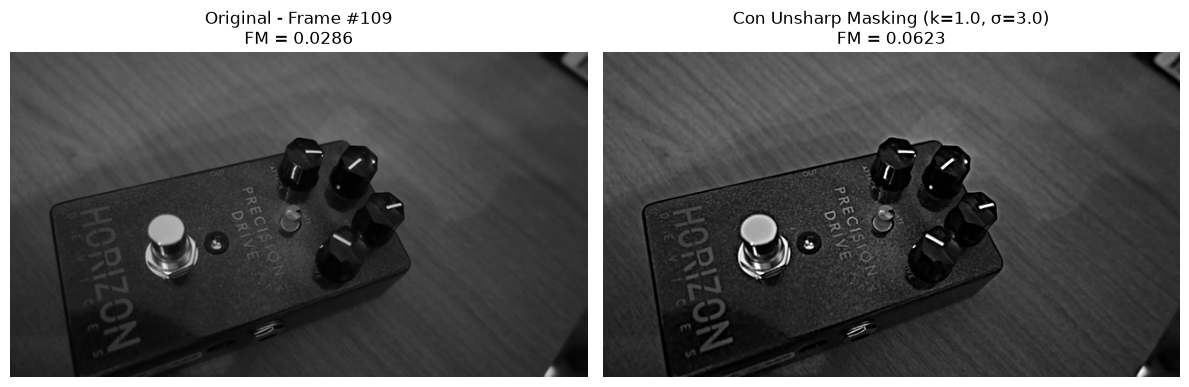

In [32]:
frame_to_show = peak_idx_full  # podés cambiar a otro frame para inspeccionar el efecto

original_img = frames_gray[frame_to_show]
sharpened_img = unsharp_mask(original_img, k=K_UNSHARP, sigma=SIGMA_UNSHARP)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(original_img, cmap='gray')
axs[0].set_title(f'Original - Frame #{frame_to_show}\nFM = {fm_full[frame_to_show]:.4f}')
axs[0].axis('off')

axs[1].imshow(sharpened_img, cmap='gray')
axs[1].set_title(f'Con Unsharp Masking (k={K_UNSHARP}, σ={SIGMA_UNSHARP})\n'
                  f'FM = {frequency_sharpness_measure(sharpened_img):.4f}')
axs[1].axis('off')

plt.tight_layout()
plt.show()

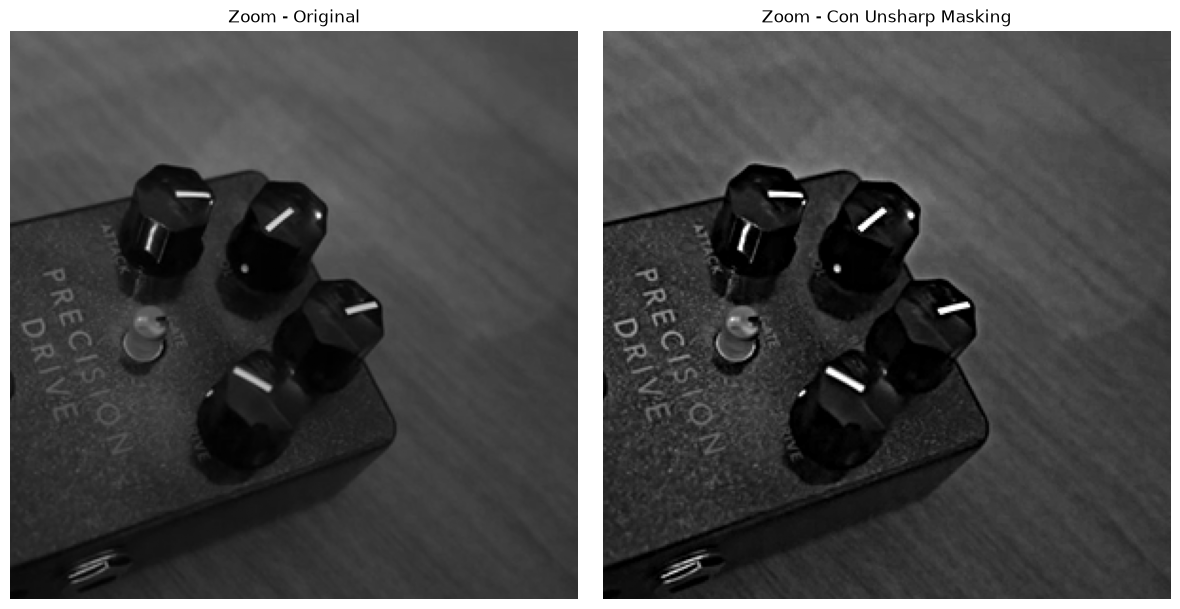

In [33]:
# Zoom sobre la zona de mayor detalle (usa el punto detectado en la Sección 7.b)
margin = 120
zy0 = max(point_full["y0"] - margin, 0)
zy1 = min(point_full["y1"] + margin, original_img.shape[0])
zx0 = max(point_full["x0"] - margin, 0)
zx1 = min(point_full["x1"] + margin, original_img.shape[1])

crop_original = original_img[zy0:zy1, zx0:zx1]
crop_sharpened = sharpened_img[zy0:zy1, zx0:zx1]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(crop_original, cmap='gray')
axs[0].set_title('Zoom - Original')
axs[0].axis('off')

axs[1].imshow(crop_sharpened, cmap='gray')
axs[1].set_title('Zoom - Con Unsharp Masking')
axs[1].axis('off')

plt.tight_layout()
plt.show()

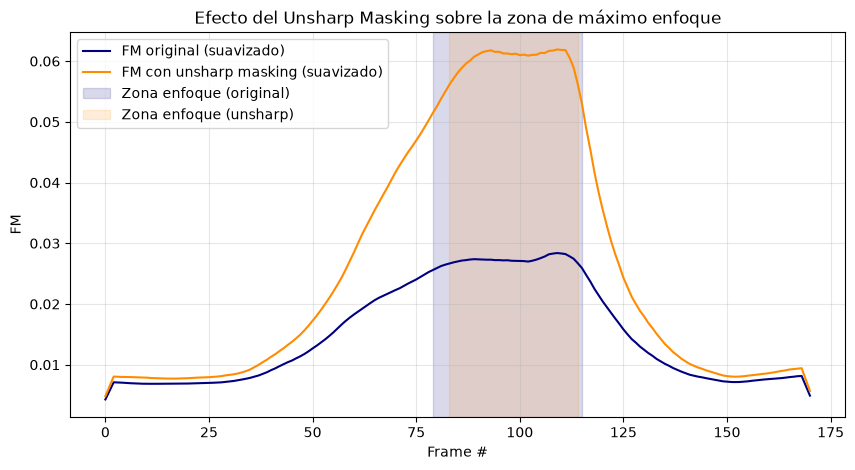

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fm_full_smooth, label='FM original (suavizado)', color='navy')
ax.plot(fm_full_unsharp_smooth, label='FM con unsharp masking (suavizado)', color='darkorange')
ax.axvspan(start_orig, end_orig, color='navy', alpha=0.15, label='Zona enfoque (original)')
ax.axvspan(start_unsharp, end_unsharp, color='darkorange', alpha=0.15, label='Zona enfoque (unsharp)')
ax.set_xlabel('Frame #')
ax.set_ylabel('FM')
ax.set_title('Efecto del Unsharp Masking sobre la zona de máximo enfoque')
ax.legend()
ax.grid(alpha=0.3)
plt.show()



## 9. Resumen de resultados

| Experimento | Frame de máximo enfoque | FM máximo |
|---|---|---|
| Frame completo | `109` | `0.0286` |
| ROI central (10%) | `101` | `0.3506` |
| Frame completo + unsharp masking | `109` | `0.0623` |
